# Clustering Analysis

**Best scheme**: Meta+TF-IDF + KMeans (k=25, silhouette=0.1476)  
**Dataset**: 21,311 NYC restaurants with 768-dim nomic embeddings + 500-dim TF-IDF features  
**Goal**: Group restaurants into semantically meaningful clusters for map overlay, search, and personalization modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

## 1. Experiment Results Comparison

We evaluated 4 schemes (2 feature sets x 2 algorithms) across an extended range of K values (5–50).  
The table below shows the best K for each scheme.

In [2]:
df_scores = pd.read_csv("../results/clustering_scores.csv")
df_scores.loc[df_scores.groupby("scheme")["silhouette"].idxmax()]\
         .sort_values("silhouette", ascending=False)\
         .reset_index(drop=True)

,scheme,k,silhouette
0,combined+kmeans,25,0.1476
1,combined+gmm,30,0.1279
2,meta+kmeans,40,0.1128
3,meta+gmm,50,0.0985


## 2. Silhouette Score vs K

The `combined+kmeans` curve (green) peaks at **k=25** (silhouette=0.1476), then drops at k=30.  
This confirms k=25 as the optimal number of clusters.

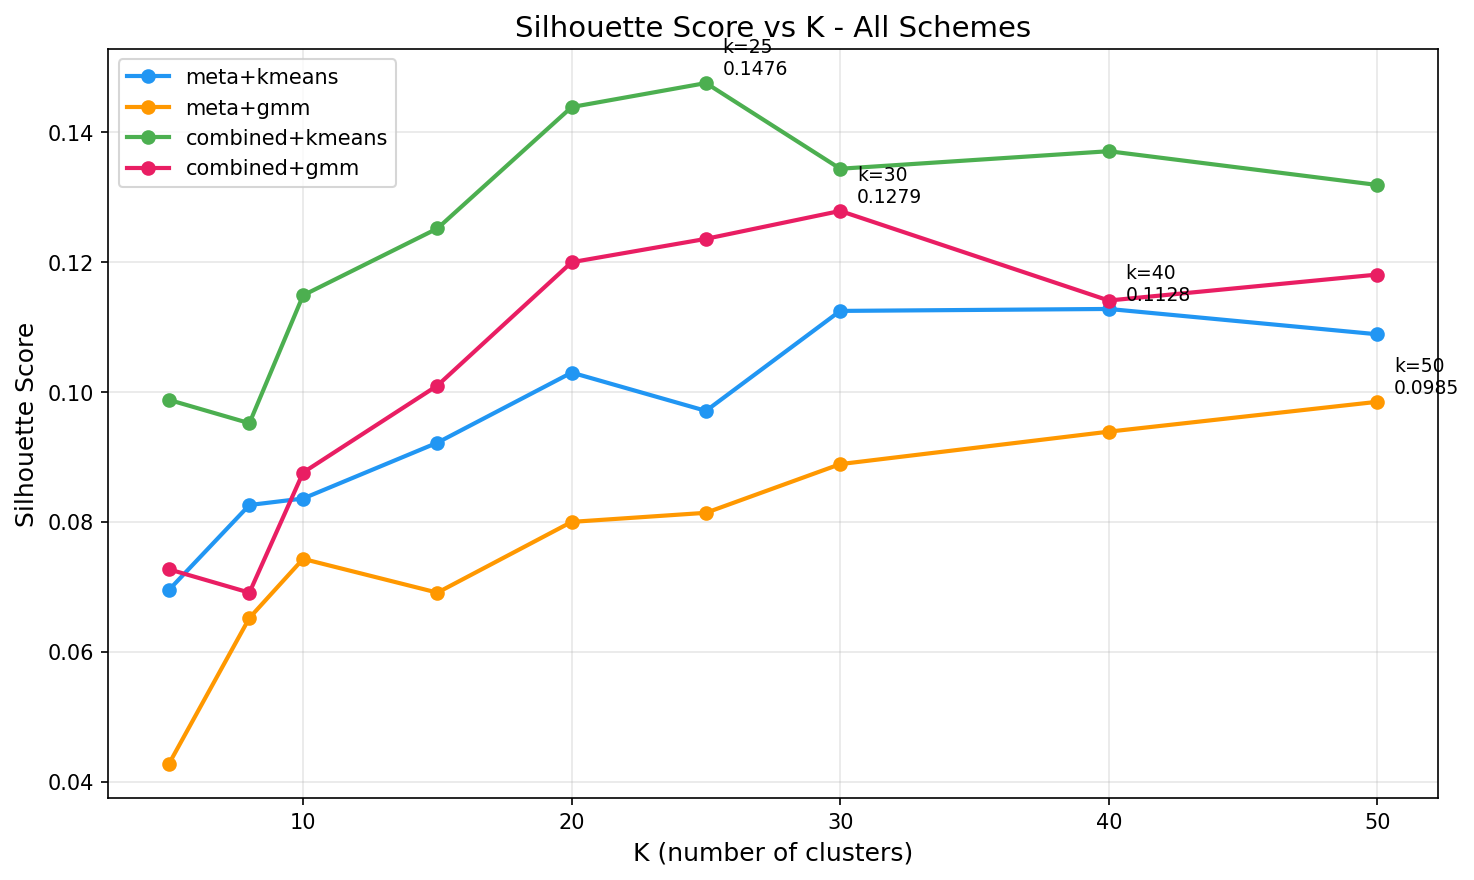

In [3]:
from IPython.display import Image
Image("../results/silhouette_vs_k.png")

## 3. UMAP Visualization — All 4 Schemes

UMAP projects the 100-dim PCA space to 2D for visual inspection.  
The bottom-left panel (`Meta+TF-IDF + KMeans`) shows the most coherent cluster boundaries.

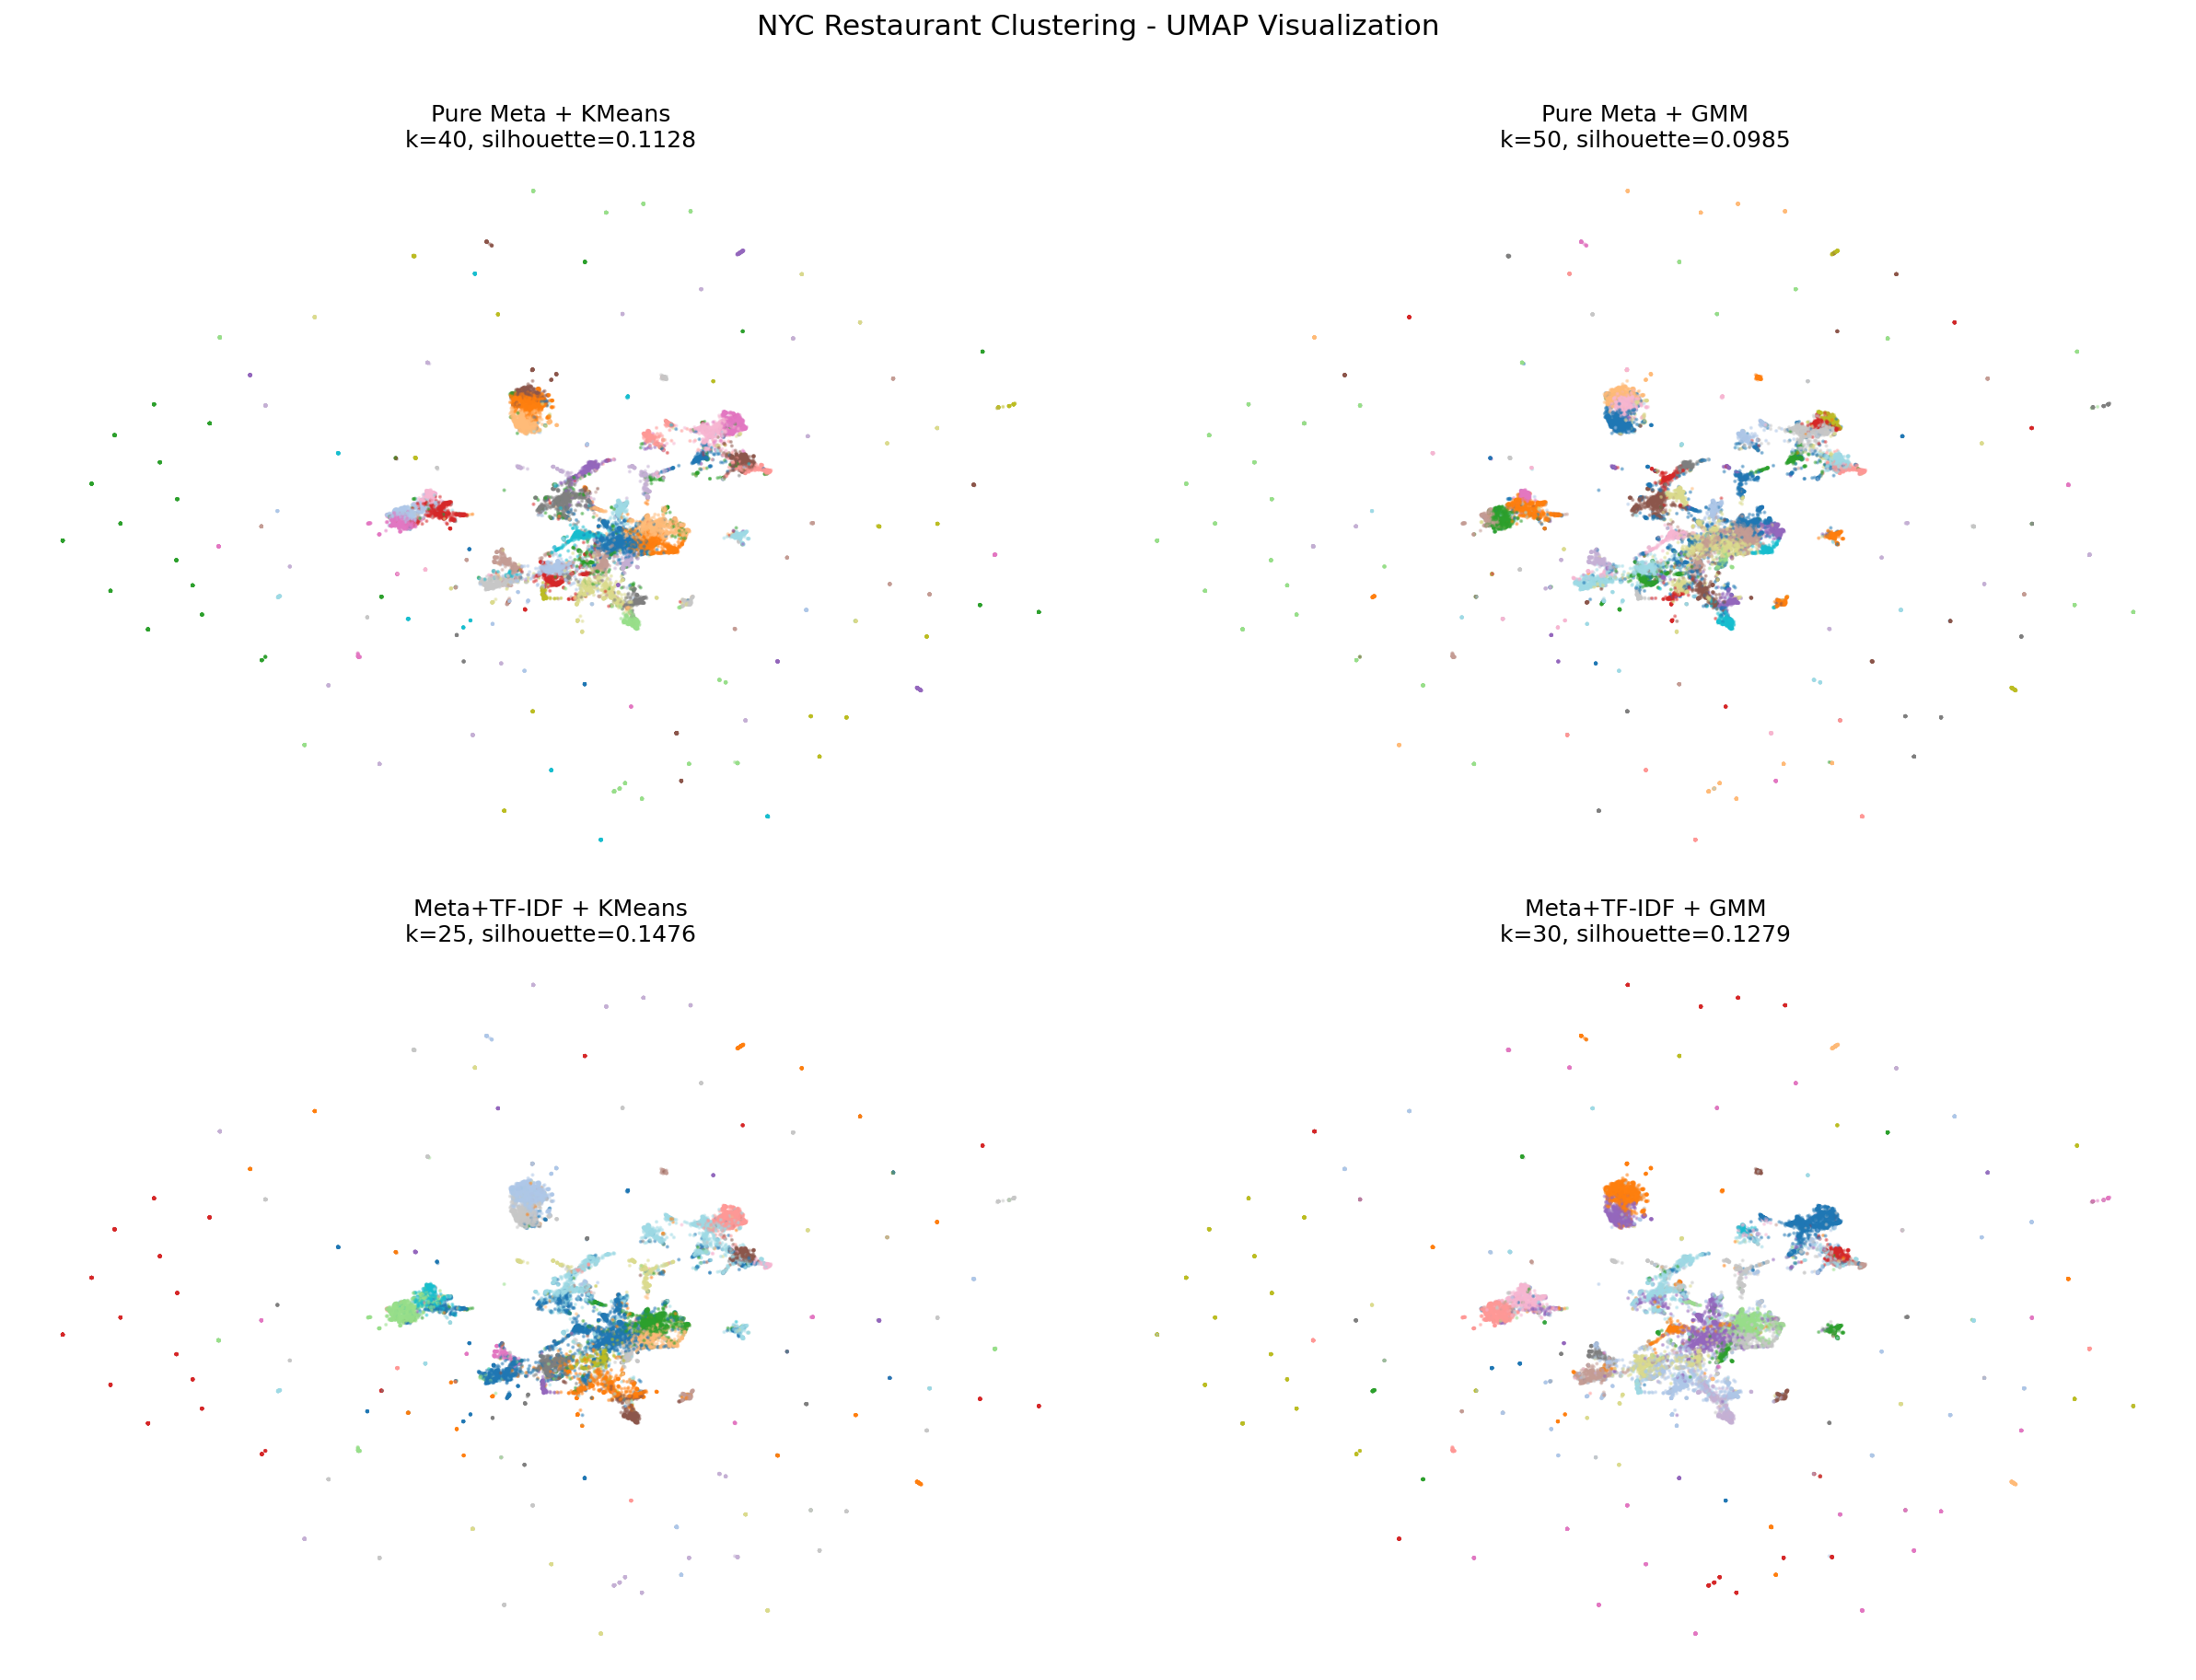

In [4]:
Image("../results/cluster_comparison_umap.png")

## 4. Cluster Size Distribution (combined+kmeans, k=25)

The distribution is intentionally uneven: large clusters capture broad dining categories,  
while small clusters isolate specific cuisine niches.

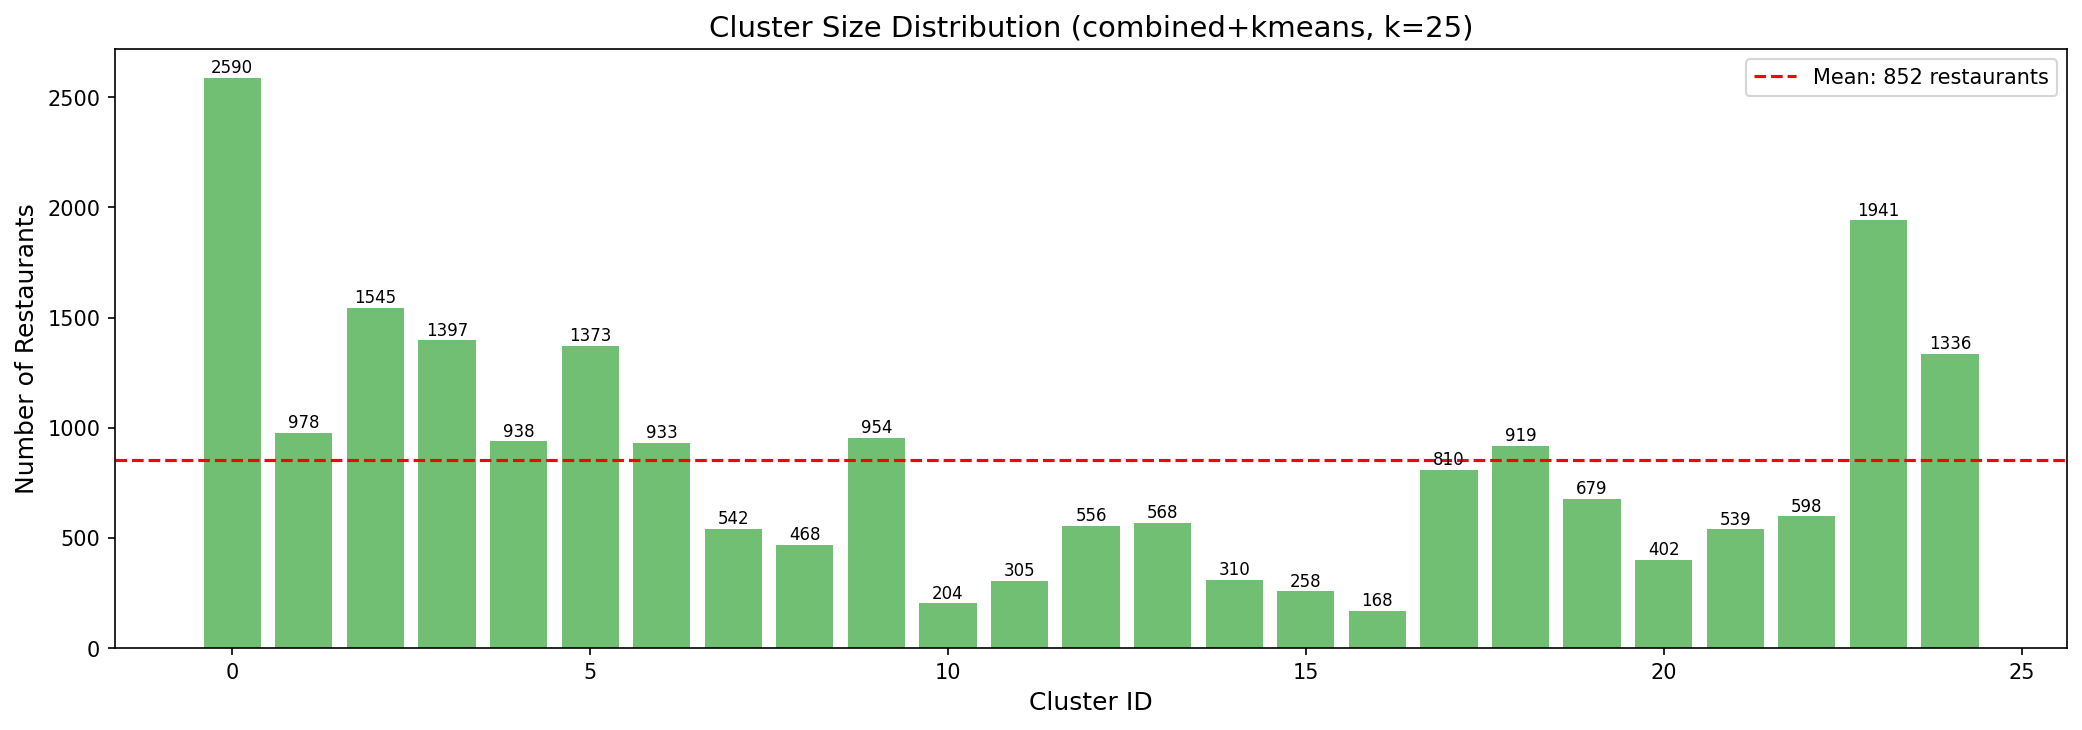

In [5]:
Image("../results/best_cluster_distribution.png")

## 5. Per-Cluster Semantic Analysis

Each cluster's identity is characterized by its top TF-IDF keywords, dominant borough, and average rating.  
Small clusters correspond to distinct cuisine types (ramen, bubble tea, bagels, ice cream),  
while large clusters represent broader categories.

In [6]:
with open("../results/cluster_summary.json") as f:
    summary = json.load(f)

df_summary = pd.DataFrame(summary)
df_summary["top_keywords_str"] = df_summary["top_keywords"].apply(lambda x: ", ".join(x[:5]))
df_summary[["cluster_id", "size", "avg_rating",
            "top_borough", "top_borough_pct",
            "top_keywords_str"]].sort_values("size", ascending=False)

,cluster_id,size,avg_rating,top_borough,top_borough_pct,top_keywords_str
0,0,2590,4.31,Manhattan,60.6,"food, great, good, service, place"
23,23,1941,4.23,Brooklyn,35.3,"food, good, great, place, service"
2,2,1545,4.14,Manhattan,30.6,"pizza, good, great, food, place"
3,3,1397,4.14,Manhattan,59.8,"food, good, great, place, service"
5,5,1373,4.30,Manhattan,50.5,"great, place, good, bar, drinks"
24,24,1336,4.26,Manhattan,51.8,"food, good, great, place, service"
1,1,978,4.36,Manhattan,42.8,"good, great, place, delicious, best"
9,9,954,4.00,Brooklyn,31.4,"food, good, chinese, great, place"
4,4,938,4.34,Manhattan,57.4,"great, good, food, place, bar"
6,6,933,4.19,Manhattan,42.6,"food, good, great, place, service"


## 6. Cluster Rating & Size Overview

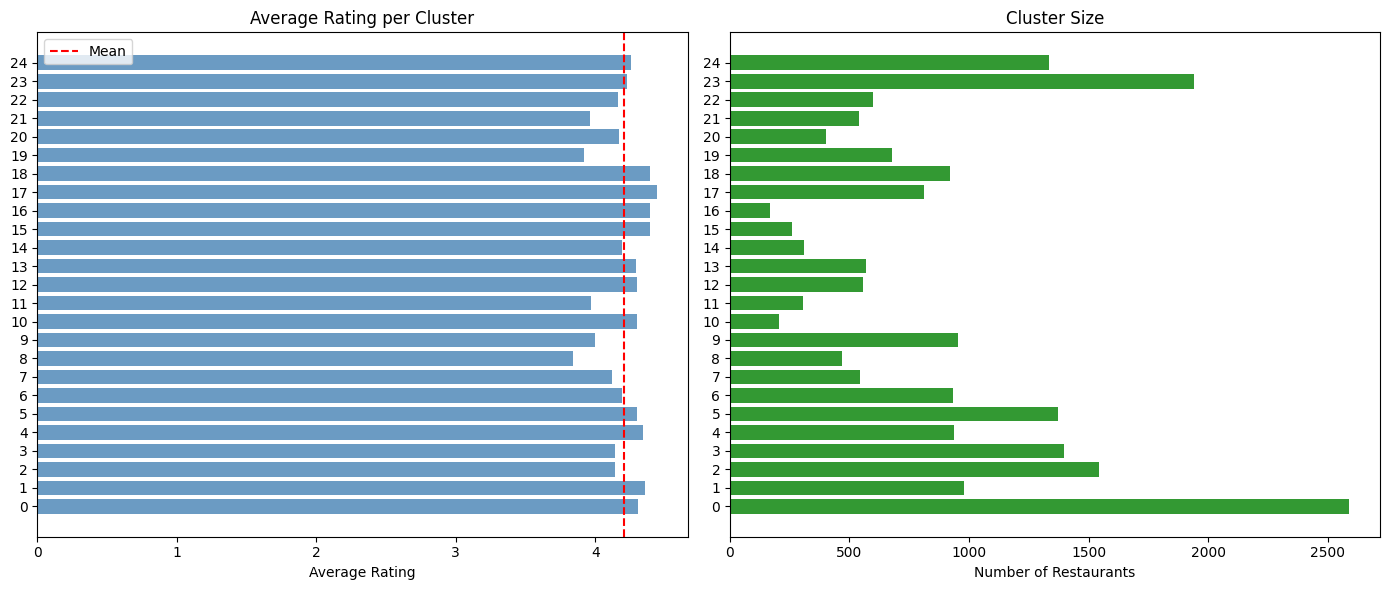

In [7]:
df_summary_sorted = df_summary.sort_values("cluster_id")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(df_summary_sorted["cluster_id"].astype(str),
             df_summary_sorted["avg_rating"], color="steelblue", alpha=0.8)
axes[0].axvline(df_summary_sorted["avg_rating"].mean(),
                color="red", linestyle="--", label="Mean")
axes[0].set_xlabel("Average Rating")
axes[0].set_title("Average Rating per Cluster")
axes[0].legend()

axes[1].barh(df_summary_sorted["cluster_id"].astype(str),
             df_summary_sorted["size"], color="green", alpha=0.8)
axes[1].set_xlabel("Number of Restaurants")
axes[1].set_title("Cluster Size")

plt.tight_layout()
plt.savefig("../results/cluster_rating_size.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Why k=25?

We selected k=25 based on both quantitative and qualitative evidence:

**Mathematical justification**: k=25 achieves the highest silhouette score (0.1476) across the entire search range (k=5–50). 

**Semantic interpretability**: At k=25, the model produces 25 clusters with the following structure:
- **10 niche clusters** with distinct cuisine identities: ramen, bubble tea, ice cream, bagels, sushi, pizza, Chinese, Italian, Thai, fried chicken
- **4 service-type clusters**: specialty coffee, Starbucks/chain coffee, Dunkin'/donuts, bars/nightlife
- **1 language-specific cluster**: restaurants with non-English (Google-translated) reviews
- **10 general dining clusters**: broad restaurant categories distinguished by borough and rating patterns

Compared to k=20, the jump to k=25 adds 5 new semantically meaningful splits (fried chicken, Dunkin', Starbucks, Italian, bars) without fragmenting existing niche clusters. Going beyond k=25 would primarily subdivide the general dining clusters further, producing smaller groups with equally generic keyword profiles.

## 8. Conclusions

**Best scheme**: Meta+TF-IDF + KMeans, k=25, Silhouette=0.1476

| Finding | Details |
|---------|--------|
| TF-IDF features help | Combined features consistently outperform pure meta embeddings across all K values |
| KMeans > GMM | KMeans yields higher silhouette scores than GMM on every feature set |
| k=25 is the peak spot | Silhouette peaks at k=25 (0.1476); extending beyond provides no benefit |
| Uneven but meaningful | Largest cluster ~2,590 vs smallest ~168; small clusters map to specific cuisines |
| Silhouette is reasonable | 0.15 is typical for high-dimensional text embedding clustering with soft semantic boundaries |

**Output files for downstream modules**:
- `results/restaurant_clusters.csv` (21,311 rows) — Ashley (map overlay), Yoonjae (personalization)
- `results/cluster_summary.json` (25 clusters) — Jacob (semantic search)